# Cook Base→Cook – Fine-Tuning TrOCR Base on Cook

Fine-tuning of `microsoft/trocr-base-handwritten` directly on the Cook dataset (no Bentham pre-training).  
Best model saved to `checkpoints/best_cook/`.

| | Value |
|---|---|
| Starting checkpoint | `microsoft/trocr-base-handwritten` |
| Train | `data/train_set_line_crops/` — 24 Seiten (ohne Val) |
| Val | `data/train_set_line_crops/` — B1_P231, B2_P224, B3_P276, B4_P282, B5_P020, B6_P020 |
| Test | `data/test_set_line_crops/` |
| Learning rate | 5e-5 |
| Epochs (max) | 20 |
| Early stopping | 3 epochs |

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import random
import numpy as np
import torch
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

ROOT             = Path("..")
TRAIN_CROPS_DIR  = ROOT / "data" / "train_set_line_crops"
TEST_CROPS_DIR   = ROOT / "data" / "test_set_line_crops"
MODEL_NAME       = "microsoft/trocr-base-handwritten"
SAVE_DIR         = ROOT / "checkpoints" / "best_cook"

# ── Hyperparameters ────────────────────────────────────────────────────────
MAX_TARGET_LENGTH   = 128
TRAIN_BATCH_SIZE    = 8
EVAL_BATCH_SIZE     = 8
LEARNING_RATE       = 5e-5
NUM_EPOCHS          = 20
EARLY_STOP_PATIENCE = 3
NUM_BEAMS           = 4

print(f"Random seed     : {SEED}")
print(f"Starting model  : {MODEL_NAME}")
for p in [TRAIN_CROPS_DIR, TEST_CROPS_DIR]:
    print(f"  {'✓' if p.exists() else '✗'} {p}")

Random seed     : 42
Starting model  : microsoft/trocr-base-handwritten
  ✓ ../data/train_set_line_crops
  ✓ ../data/test_set_line_crops


## Step 1 – Load Data

In [2]:
import pandas as pd

def build_dataframe(crops_dir: Path) -> pd.DataFrame:
    records = []
    for page_dir in sorted(crops_dir.iterdir()):
        if not page_dir.is_dir():
            continue
        for img_path in sorted(page_dir.glob("*.jpg")):
            txt_path = img_path.with_suffix(".txt")
            if txt_path.exists():
                transcription = txt_path.read_text(encoding="utf-8").strip()
                records.append({
                    "image_path":    str(img_path),
                    "page":          page_dir.name,
                    "transcription": transcription,
                })
    return pd.DataFrame(records)


df_all_train = build_dataframe(TRAIN_CROPS_DIR)
df_test      = build_dataframe(TEST_CROPS_DIR)

VAL_PAGES = {"B1_P231", "B2_P224", "B3_P276", "B4_P282", "B5_P020", "B6_P020"}

df_train = df_all_train[~df_all_train["page"].isin(VAL_PAGES)].reset_index(drop=True)
df_val   = df_all_train[ df_all_train["page"].isin(VAL_PAGES)].reset_index(drop=True)

print(f"Train pages : {sorted(df_train['page'].unique())}")
print(f"Val pages   : {sorted(df_val['page'].unique())}")
print(f"Test pages  : {sorted(df_test['page'].unique())}")
print()
print(f"Train lines : {len(df_train):>5}")
print(f"Val lines   : {len(df_val):>5}")
print(f"Test lines  : {len(df_test):>5}")

Train pages : ['B1_P057', 'B1_P108', 'B1_P146', 'B1_P151', 'B2_P014', 'B2_P025', 'B2_P052', 'B2_P094', 'B3_P015', 'B3_P069', 'B3_P105', 'B3_P189', 'B4_P019', 'B4_P071', 'B4_P123', 'B4_P171', 'B5_P014', 'B5_P015', 'B5_P016', 'B5_P017', 'B6_P014', 'B6_P015', 'B6_P016', 'B6_P017']
Val pages   : ['B1_P231', 'B2_P224', 'B3_P276', 'B4_P282', 'B5_P020', 'B6_P020']
Test pages  : ['B1_P_206', 'B2_P_260', 'B3_P_162', 'B4_P_178', 'B5_P_279', 'B6_P_060']

Train lines :   726
Val lines   :   194
Test lines  :   189


## Step 2 – Build Dataset Objects

In [3]:
from transformers import TrOCRProcessor
from PIL import Image

processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
print(f"Processor loaded from: {MODEL_NAME}")

Processor loaded from: microsoft/trocr-base-handwritten


In [4]:
from torch.utils.data import Dataset, DataLoader


class CookDataset(Dataset):
    def __init__(self, df, processor, max_target_length=MAX_TARGET_LENGTH):
        self.df                = df
        self.processor         = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        pixel_values = self.processor(
            images=img, return_tensors="pt"
        ).pixel_values.squeeze(0)

        labels = self.processor.tokenizer(
            row["transcription"],
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {"pixel_values": pixel_values, "labels": labels}


train_dataset = CookDataset(df_train, processor)
val_dataset   = CookDataset(df_val,   processor)
test_dataset  = CookDataset(df_test,  processor)

train_loader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=EVAL_BATCH_SIZE,  shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=EVAL_BATCH_SIZE,  shuffle=False, num_workers=0)

sample = train_dataset[0]
print(f"pixel_values : {sample['pixel_values'].shape}")
print(f"labels       : {sample['labels'].shape}")
print("DataLoaders OK.")

pixel_values : torch.Size([3, 384, 384])
labels       : torch.Size([128])
DataLoaders OK.


## Step 3 – Load & Configure Model

In [5]:
from transformers import VisionEncoderDecoderModel
import gc

# Release any memory held by previous runs or other notebook kernels
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated(device) / 1024**3
    reserved  = torch.cuda.memory_reserved(device)  / 1024**3
    total     = torch.cuda.get_device_properties(device).total_memory / 1024**3
    print(f"Device : {device}  —  {total:.1f} GB total  |  {reserved:.1f} GB reserved  |  {allocated:.1f} GB allocated")
else:
    print(f"Device : {device}")

model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.eos_token_id           = processor.tokenizer.sep_token_id
model.config.use_cache              = False
model.gradient_checkpointing_enable()

model.to(device)
print(f"Model loaded from : {MODEL_NAME}")
print("Gradient checkpointing active.")

Device : cuda  —  11.6 GB total  |  0.0 GB reserved  |  0.0 GB allocated


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded from : microsoft/trocr-base-handwritten
Gradient checkpointing active.


In [6]:
from torch.optim import AdamW
from transformers import get_scheduler

WARMUP_RATIO = 0.1

total_steps  = NUM_EPOCHS * len(train_loader)
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")
print(f"Optimizer            : AdamW, LR={LEARNING_RATE}")
print(f"Scheduler            : Linear Warmup → Linear Decay")

Total training steps : 1820
Warmup steps         : 182
Optimizer            : AdamW, LR=5e-05
Scheduler            : Linear Warmup → Linear Decay


## Step 4 – Training Loop

Per epoch: train → validation CER → save best checkpoint → early stopping.  
Best model saved to `checkpoints/best_cook/`.

In [7]:
import evaluate

cer_metric = evaluate.load("cer")


def compute_cer(model, dataloader, processor, device):
    model.eval()
    all_preds, all_refs = [], []
    with torch.no_grad():
        for batch in dataloader:
            pixel_values  = batch["pixel_values"].to(device)
            labels        = batch["labels"].clone()
            generated_ids = model.generate(pixel_values, max_new_tokens=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS)
            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs  = processor.batch_decode(labels, skip_special_tokens=True)
            all_preds.extend(preds)
            all_refs.extend(refs)
    return cer_metric.compute(predictions=all_preds, references=all_refs)

In [8]:
from tqdm.notebook import tqdm

SAVE_DIR.mkdir(parents=True, exist_ok=True)

best_cer         = float("inf")
patience_counter = 0
history          = []
scaler           = torch.amp.GradScaler("cuda")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Training ────────────────────────────────────────────────────────────
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [train]", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            outputs = model(pixel_values=pixel_values, labels=labels)
        scaler.scale(outputs.loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += outputs.loss.item()

    avg_loss = total_loss / len(train_loader)

    # ── Validation CER ──────────────────────────────────────────────────────
    val_cer = compute_cer(model, val_loader, processor, device)

    history.append({"epoch": epoch, "train_loss": avg_loss, "val_cer": val_cer})
    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Val CER: {val_cer:.4f}", end="")

    # ── Checkpoint & Early Stopping ─────────────────────────────────────────
    if val_cer < best_cer:
        best_cer         = val_cer
        patience_counter = 0
        model.save_pretrained(SAVE_DIR)
        processor.save_pretrained(SAVE_DIR)
        print(f"  ✓ Best model saved")
    else:
        patience_counter += 1
        print(f"  ✗ No improvement ({patience_counter}/{EARLY_STOP_PATIENCE})")
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping after epoch {epoch} — best Val CER: {best_cer:.4f}")
            break

Epoch 01/20 [train]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 01 | Loss: 2.8681 | Val CER: 0.1010

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved


Epoch 02/20 [train]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 02 | Loss: 2.1145 | Val CER: 0.4404  ✗ No improvement (1/3)


Epoch 03/20 [train]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 03 | Loss: 2.3587 | Val CER: 0.4473  ✗ No improvement (2/3)


Epoch 04/20 [train]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 04 | Loss: 1.6048 | Val CER: 0.3971  ✗ No improvement (3/3)

Early stopping after epoch 4 — best Val CER: 0.1010


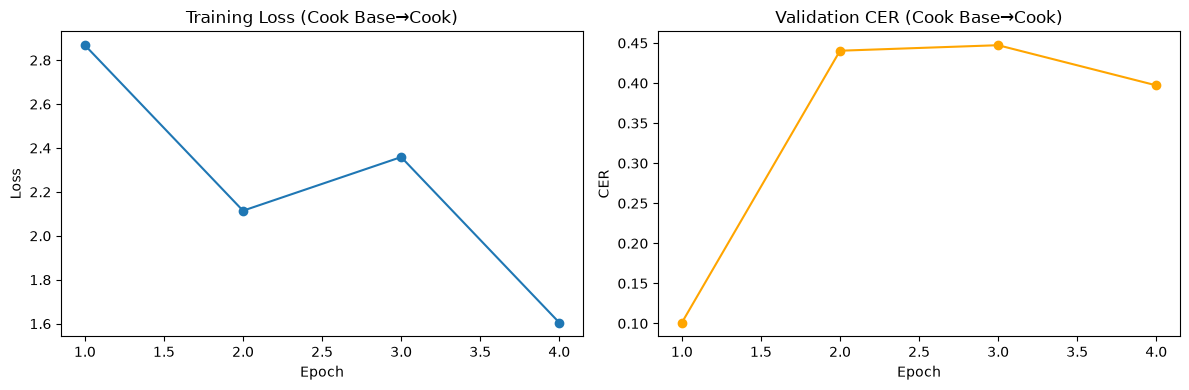


Best Val CER: 0.1010 (Epoch 1)


In [9]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_df["epoch"], history_df["train_loss"], marker="o")
ax1.set_title("Training Loss (Cook Base→Cook)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax2.plot(history_df["epoch"], history_df["val_cer"], marker="o", color="orange")
ax2.set_title("Validation CER (Cook Base→Cook)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("CER")
plt.tight_layout()
plt.show()
print(f"\nBest Val CER: {history_df['val_cer'].min():.4f} (Epoch {history_df['val_cer'].idxmin() + 1})")

## Step 5 – Evaluation

Load best checkpoint → CER & WER on all splits.  
Self-contained: can be run after a kernel restart without retraining.

In [10]:
import torch
import evaluate
import pandas as pd
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from transformers import VisionEncoderDecoderModel, TrOCRProcessor

ROOT     = Path("..")
SAVE_DIR = ROOT / "checkpoints" / "best_cook"
device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_model     = VisionEncoderDecoderModel.from_pretrained(SAVE_DIR).to(device)
best_processor = TrOCRProcessor.from_pretrained(SAVE_DIR)
best_model.eval()

print(f"Device     : {device}")
print(f"Checkpoint : {SAVE_DIR}")

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Device     : cuda
Checkpoint : ../checkpoints/best_cook


In [11]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

MAX_TARGET_LENGTH = 128
EVAL_BATCH_SIZE   = 8
NUM_BEAMS         = 4


class _CookDataset(Dataset):
    def __init__(self, df, processor):
        self.df, self.processor = df, processor

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            row["transcription"], padding="max_length",
            max_length=MAX_TARGET_LENGTH, truncation=True, return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}


def evaluate_split(df_split, label):
    loader = DataLoader(
        _CookDataset(df_split, best_processor),
        batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0,
    )
    all_preds, all_refs = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Eval {label}", leave=False):
            pixel_values  = batch["pixel_values"].to(device)
            labels        = batch["labels"].clone()
            generated_ids = best_model.generate(pixel_values, max_new_tokens=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS)
            preds = best_processor.batch_decode(generated_ids, skip_special_tokens=True)
            labels[labels == -100] = best_processor.tokenizer.pad_token_id
            refs  = best_processor.batch_decode(labels, skip_special_tokens=True)
            all_preds.extend(preds)
            all_refs.extend(refs)
    cer = cer_metric.compute(predictions=all_preds, references=all_refs)
    wer = wer_metric.compute(predictions=all_preds, references=all_refs)
    return cer, wer, all_preds, all_refs


# Rebuild DataFrames (self-contained after kernel restart)
TRAIN_CROPS_DIR = ROOT / "data" / "train_set_line_crops"
TEST_CROPS_DIR  = ROOT / "data" / "test_set_line_crops"
VAL_PAGES       = {"B1_P231", "B2_P224", "B3_P276", "B4_P282", "B5_P020", "B6_P020"}

def _build_df(crops_dir):
    records = []
    for page_dir in sorted(Path(crops_dir).iterdir()):
        if not page_dir.is_dir(): continue
        for img_path in sorted(page_dir.glob("*.jpg")):
            txt_path = img_path.with_suffix(".txt")
            if txt_path.exists():
                records.append({"image_path": str(img_path), "page": page_dir.name,
                                 "transcription": txt_path.read_text(encoding="utf-8").strip()})
    return pd.DataFrame(records)

df_all  = _build_df(TRAIN_CROPS_DIR)
df_test = _build_df(TEST_CROPS_DIR)
df_train_eval = df_all[~df_all["page"].isin(VAL_PAGES)].reset_index(drop=True)
df_val_eval   = df_all[ df_all["page"].isin(VAL_PAGES)].reset_index(drop=True)

train_cer, train_wer, train_preds, train_refs = evaluate_split(df_train_eval, "Train")
val_cer,   val_wer,   val_preds,   val_refs   = evaluate_split(df_val_eval,   "Val")
test_cer,  test_wer,  test_preds,  test_refs  = evaluate_split(df_test,       "Test")

results = pd.DataFrame([
    {"Split": "Train", "Lines": len(train_refs), "CER": round(train_cer, 4), "WER": round(train_wer, 4)},
    {"Split": "Val",   "Lines": len(val_refs),   "CER": round(val_cer,   4), "WER": round(val_wer,   4)},
    {"Split": "Test",  "Lines": len(test_refs),  "CER": round(test_cer,  4), "WER": round(test_wer,  4)},
])
print(results.to_string(index=False))

Eval Train:   0%|          | 0/91 [00:00<?, ?it/s]

Eval Val:   0%|          | 0/25 [00:00<?, ?it/s]

Eval Test:   0%|          | 0/24 [00:00<?, ?it/s]

Split  Lines    CER    WER
Train    726 0.0766 0.1886
  Val    194 0.1010 0.2559
 Test    189 0.1208 0.2900


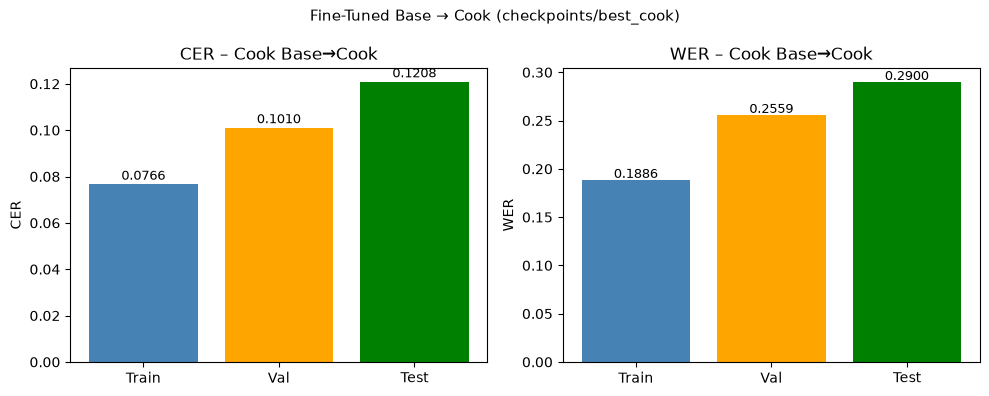

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x      = range(len(results))
colors = ["steelblue", "orange", "green"]

for ax, metric in zip(axes, ["CER", "WER"]):
    ax.bar(x, results[metric], color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(results["Split"])
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} – Cook Base→Cook")
    for i, v in enumerate(results[metric]):
        ax.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("Fine-Tuned Base → Cook (checkpoints/best_cook)", fontsize=11)
plt.tight_layout()
plt.show()

## Step 6 – Qualitative Examples (Test Set)

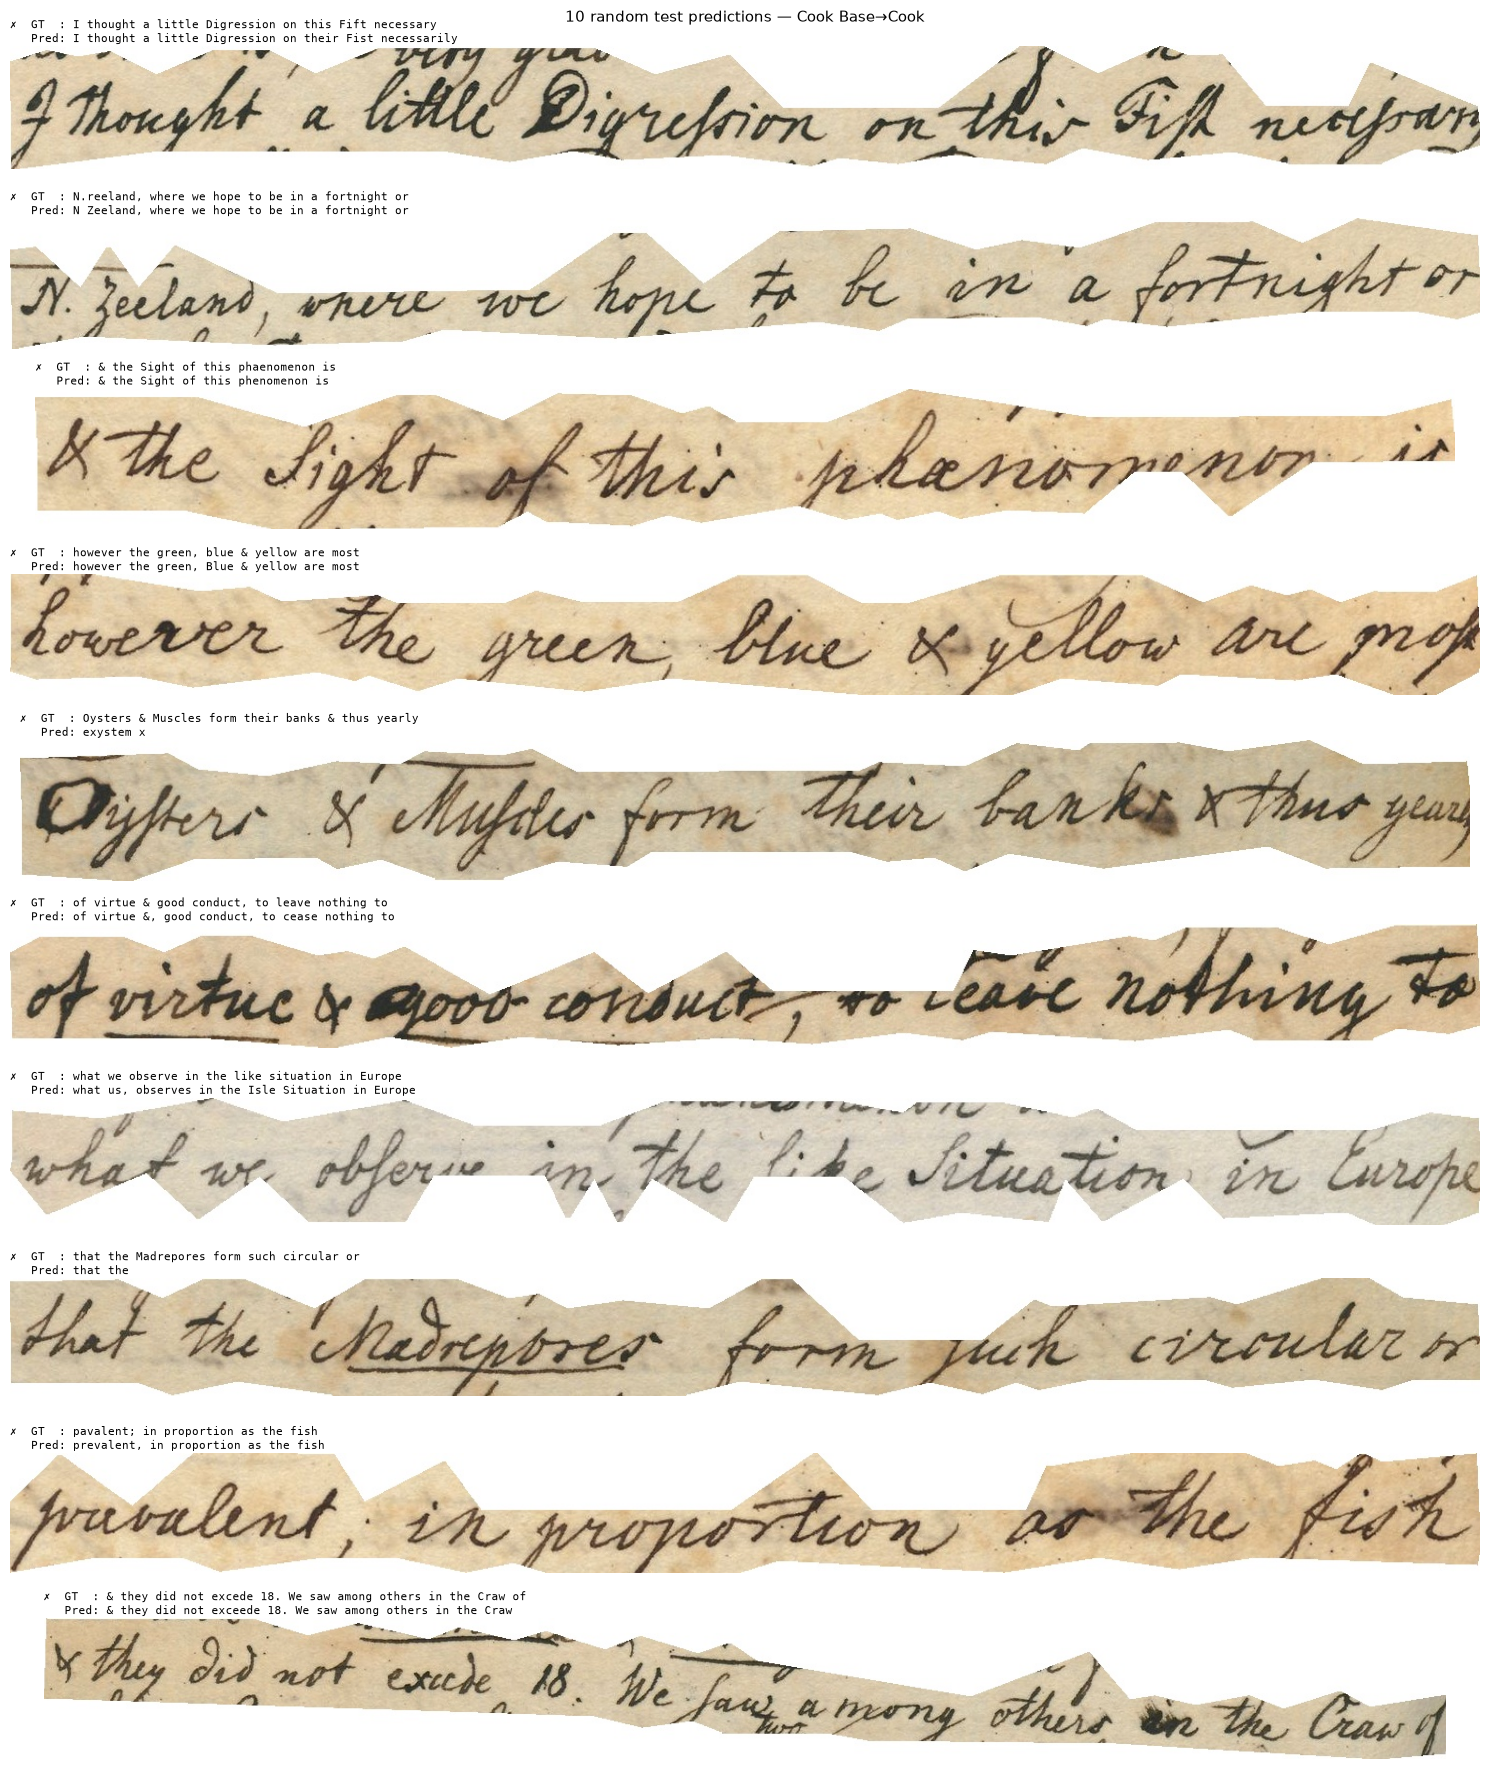

In [13]:
import random
SEED = 42

sample_idx = df_test.sample(10, random_state=SEED).index.tolist()

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, idx in zip(axes, sample_idx):
    row   = df_test.iloc[idx]
    img   = Image.open(row["image_path"]).convert("RGB")
    pred  = test_preds[idx]
    ref   = test_refs[idx]
    match = "✓" if pred.strip() == ref.strip() else "✗"
    ax.imshow(img)
    ax.set_title(
        f"{match}  GT  : {ref}\n   Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")
plt.suptitle("10 random test predictions — Cook Base→Cook", fontsize=11)
plt.tight_layout()
plt.show()

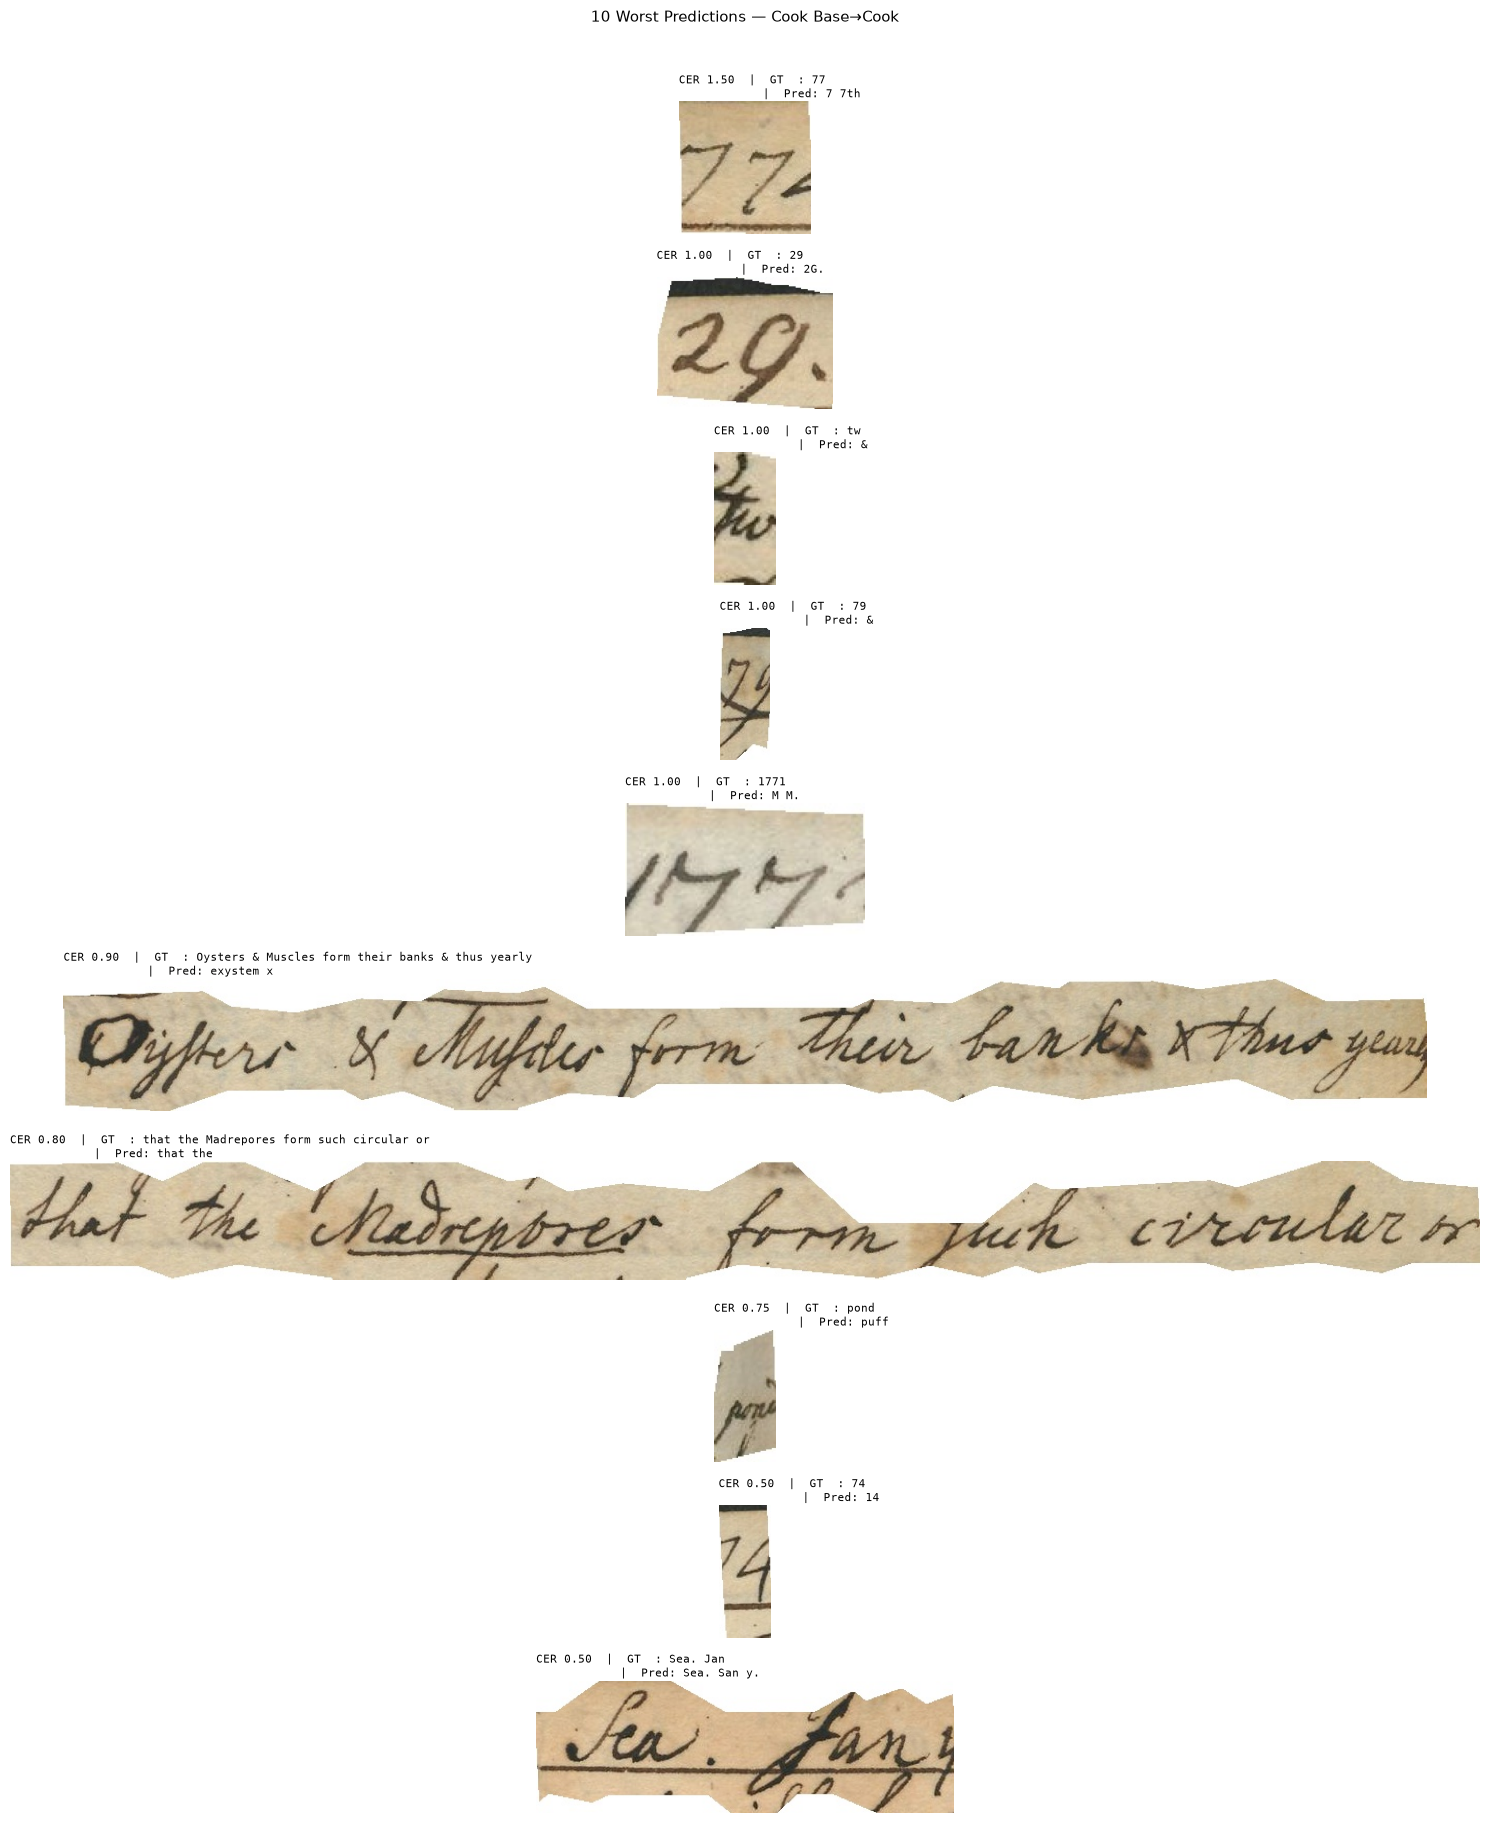

In [14]:
from jiwer import cer as line_cer

errors = sorted(
    [(line_cer(ref, pred), idx, ref, pred)
     for idx, (pred, ref) in enumerate(zip(test_preds, test_refs)) if ref.strip()],
    reverse=True,
)

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, (c, idx, ref, pred) in zip(axes, errors[:10]):
    row = df_test.iloc[idx]
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f"CER {c:.2f}  |  GT  : {ref}\n"
        f"            |  Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")

plt.suptitle("10 Worst Predictions — Cook Base→Cook", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()